In [1]:
from typing import TypedDict

from dotenv import  load_dotenv
from langchain_core.messages import HumanMessage
from langchain_deepseek import ChatDeepSeek
from langgraph.checkpoint.memory import InMemorySaver
from langgraph.graph import StateGraph,START,END
from loguru import logger
from langchain.chat_models import init_chat_model
from rich import print as rprint
import os

from dotenv import load_dotenv
load_dotenv(override=True)

GEMINI_API_KEY=os.getenv("GEMINI_API_KEY")
GEMINI_BASE_URL=os.getenv("GEMINI_BASE_URL")

model = init_chat_model(
  model="gemini-3.1-flash-lite",
  model_provider="google_genai",
  api_key=GEMINI_API_KEY,
  transport="rest"  # 强制使用 REST 协议
)

#1. 声明状态
class OverAllState(TypedDict):
    topic:str
    poem:str
    joke:str
    final_output:str

#1.1 输入状态
class InputState(TypedDict):
    topic:str

#1.2 输出状态
class OutputState(TypedDict):
    final_output:str

#2. 声明节点
def node_poem(state:InputState) -> OverAllState:
    logger.info("node_poem正在执行")
    topic = state["topic"]
    poem = model.invoke([HumanMessage(f"写一首关于{topic}的七言绝句")]).content

    return {
        "poem":poem
    }

def node_joke(state:InputState) -> OverAllState:
    logger.info("node_joke正在执行")
    topic = state["topic"]
    joke = model.invoke([HumanMessage(f"写一首关于{topic}的笑话")]).content
    return {
        "joke":joke
    }

def node_output(state:OverAllState)->OutputState:
    logger.info("node_output正在执行")
    topic = state["topic"]
    poem = state["poem"]
    joke = state["joke"]
    final_output = f"关于{topic}主题的七言绝句:{poem},\n笑话:{joke}\n"
    return {
        "final_output":final_output
    }

#3. 构建图的结构
builder = StateGraph(state_schema=OverAllState,input_schema=InputState,output_schema=OutputState)
#3.1 添加节点
builder.add_node("node_poem",node_poem)
builder.add_node("node_joke",node_joke)
builder.add_node("node_output",node_output)
builder.add_edge(START,"node_poem")
builder.add_edge(START,"node_joke")
builder.add_edge("node_poem","node_output")
builder.add_edge("node_joke","node_output")
builder.add_edge("node_output",END)

#4. 添加检查点
checkpointer = InMemorySaver()
config = {
    "configurable":{
        "thread_id":"123"
    }
}

#5. 编译执行
graph = builder.compile(checkpointer=checkpointer)
res = graph.invoke({"topic":"莲花"},config=config)
rprint(res)



2026-08-13 21:22:45.058 | INFO     | __main__:node_joke:52 - node_joke正在执行
2026-08-13 21:22:45.058 | INFO     | __main__:node_poem:43 - node_poem正在执行
2026-08-13 21:22:51.662 | INFO     | __main__:node_output:60 - node_output正在执行


{
    'final_output': "关于莲花主题的七言绝句:[{'type': 'text', 'text': 
'为您创作了一首咏莲的七言绝句：\\n\\n**《咏莲》**\\n\\n**碧水盈盈映翠盘，清风送爽晚凉寒。**\\n**出淤不染尘中色，独
倚香腮露正团。**\\n\\n---\\n**诗意赏析：**\\n*   **首句：** 描写荷叶如碧盘般铺展在盈盈水面，色泽清翠。\\n*   
**次句：** 傍晚时分，微风拂过，带走暑气，带来阵阵清凉。\\n*   **三句：** 
赞美莲花“出淤泥而不染”的孤高品格，不沾染尘世的浑浊。\\n*   **末句：** 
描写荷花花瓣上缀满露珠，好似娇羞的粉腮，静静伫立在风中。', 'extras': {'signature': 
'EnEKbwERTTIPWYvA0LirB+AX2yUQvxBAzqrZxqjOkhP5HNBx+FY/ecBZ8e4I7iQeSwKkkuCrDqfnpCHSRXPcQN/IIb9DmjiJXT6v06fEclnHK740CT
TsoloQf4VJOei6eufCdcv7NZflO/KqDOZBqpUp9w=='}}],\n笑话:[{'type': 'text', 'text': 
'这是一首关于莲花的“冷笑话”诗，请笑纳：\\n\\n**《莲花的烦恼》**\\n\\n淤泥之中练深蹲，\\n只为出水显真身。\\n路人惊叹
真清雅，\\n哪知姐在水底……憋着气，还在补妆呢！', 'extras': {'signature': 
'EnEKbwERTTIPGb7TENps5flU0liHUQACmDMNd7651eZbEVBAZvW3g5CsKE6OCIndrhqfOy7oZXGFY3TWfgvb/FbensgtYvJxBS+hoh1p/CywxecTA3
N7AUyKyGsgAWy4j2qwRbJMWE4x2cBtCrPsFBxBjQ=='}}]\n"
}

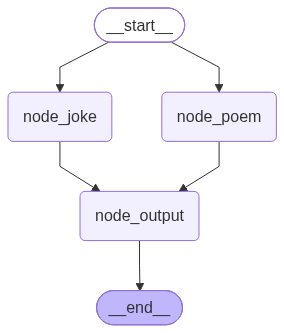

---
config:
  flowchart:
    curve: linear
---
graph TD;
	__start__([<p>__start__</p>]):::first
	node_poem(node_poem)
	node_joke(node_joke)
	node_output(node_output)
	__end__([<p>__end__</p>]):::last
	__start__ --> node_joke;
	__start__ --> node_poem;
	node_joke --> node_output;
	node_poem --> node_output;
	node_output --> __end__;
	classDef default fill:#f2f0ff,line-height:1.2
	classDef first fill-opacity:0
	classDef last fill:#bfb6fc



In [2]:
from IPython.display import  display
display(graph)

raw_mermaid = graph.get_graph().draw_mermaid()
print(raw_mermaid)

In [6]:
history_checkpoints = list(graph.get_state_history(config=config))
rprint(history_checkpoints)

[
    StateSnapshot(
        values={
            'topic': '莲花',
            'poem': [
                {
                    'type': 'text',
                    'text': 
'为您创作了一首咏莲的七言绝句：\n\n**《咏莲》**\n\n**碧水盈盈映翠盘，清风送爽晚凉寒。**\n**出淤不染尘中色，独倚香腮
露正团。**\n\n---\n**诗意赏析：**\n*   **首句：** 描写荷叶如碧盘般铺展在盈盈水面，色泽清翠。\n*   **次句：** 
傍晚时分，微风拂过，带走暑气，带来阵阵清凉。\n*   **三句：** 
赞美莲花“出淤泥而不染”的孤高品格，不沾染尘世的浑浊。\n*   **末句：** 
描写荷花花瓣上缀满露珠，好似娇羞的粉腮，静静伫立在风中。',
                    'extras': {
                        'signature': 
'EnEKbwERTTIPWYvA0LirB+AX2yUQvxBAzqrZxqjOkhP5HNBx+FY/ecBZ8e4I7iQeSwKkkuCrDqfnpCHSRXPcQN/IIb9DmjiJXT6v06fEclnHK740CT
TsoloQf4VJOei6eufCdcv7NZflO/KqDOZBqpUp9w=='
                    }
                }
            ],
            'joke': [
                {
                    'type': 'text',
                    'text': 
'这是一首关于莲花的“冷笑话”诗，请笑纳：\n\n**《莲花的烦恼》**\n\n淤泥之中练深蹲，\n只为出水显真身。\n路人惊叹真清雅
，\n哪知姐在水底……憋着气，还在补妆呢！',
                    'extras': {
                        'signature': 
'EnEKbwERTTIPGb7TENps5flU0liHUQACmDMNd7651eZbEVBAZvW3g5CsKE6OCIndrhqfOy7oZXGFY3TWfgvb/FbensgtYvJxBS+hoh1p/CywxecTA3
N7AUyKyGsgAWy4j2qwRbJMWE4x2cBtCrPsFBxBjQ=='
                    }
                }
            ],
            'final_output': "关于莲花主题的七言绝句:[{'type': 'text', 'text': 
'为您创作了一首咏莲的七言绝句：\\n\\n**《咏莲》**\\n\\n**碧水盈盈映翠盘，清风送爽晚凉寒。**\\n**出淤不染尘中色，独
倚香腮露正团。**\\n\\n---\\n**诗意赏析：**\\n*   **首句：** 描写荷叶如碧盘般铺展在盈盈水面，色泽清翠。\\n*   
**次句：** 傍晚时分，微风拂过，带走暑气，带来阵阵清凉。\\n*   **三句：** 
赞美莲花“出淤泥而不染”的孤高品格，不沾染尘世的浑浊。\\n*   **末句：** 
描写荷花花瓣上缀满露珠，好似娇羞的粉腮，静静伫立在风中。', 'extras': {'signature': 
'EnEKbwERTTIPWYvA0LirB+AX2yUQvxBAzqrZxqjOkhP5HNBx+FY/ecBZ8e4I7iQeSwKkkuCrDqfnpCHSRXPcQN/IIb9DmjiJXT6v06fEclnHK740CT
TsoloQf4VJOei6eufCdcv7NZflO/KqDOZBqpUp9w=='}}],\n笑话:[{'type': 'text', 'text': 
'这是一首关于莲花的“冷笑话”诗，请笑纳：\\n\\n**《莲花的烦恼》**\\n\\n淤泥之中练深蹲，\\n只为出水显真身。\\n路人惊叹
真清雅，\\n哪知姐在水底……憋着气，还在补妆呢！', 'extras': {'signature': 
'EnEKbwERTTIPGb7TENps5flU0liHUQACmDMNd7651eZbEVBAZvW3g5CsKE6OCIndrhqfOy7oZXGFY3TWfgvb/FbensgtYvJxBS+hoh1p/CywxecTA3
N7AUyKyGsgAWy4j2qwRbJMWE4x2cBtCrPsFBxBjQ=='}}]\n"
        },
        next=(),
        config={
            'configurable': {
                'thread_id': '123',
                'checkpoint_ns': '',
                'checkpoint_id': '1f1971a1-5d85-67de-8002-1d27b01b333a'
            }
        },
        metadata={'source': 'loop', 'step': 2, 'parents': {}},
        created_at='2026-08-13T13:22:51.663959+00:00',
        parent_config={
            'configurable': {
                'thread_id': '123',
                'checkpoint_ns': '',
                'checkpoint_id': '1f1971a1-5d82-60a2-8001-31966b253e74'
            }
        },
        tasks=(),
        interrupts=()
    ),
    StateSnapshot(
        values={
            'topic': '莲花',
            'poem': [
                {
                    'type': 'text',
                    'text': 
'为您创作了一首咏莲的七言绝句：\n\n**《咏莲》**\n\n**碧水盈盈映翠盘，清风送爽晚凉寒。**\n**出淤不染尘中色，独倚香腮
露正团。**\n\n---\n**诗意赏析：**\n*   **首句：** 描写荷叶如碧盘般铺展在盈盈水面，色泽清翠。\n*   **次句：** 
傍晚时分，微风拂过，带走暑气，带来阵阵清凉。\n*   **三句：** 
赞美莲花“出淤泥而不染”的孤高品格，不沾染尘世的浑浊。\n*   **末句：** 
描写荷花花瓣上缀满露珠，好似娇羞的粉腮，静静伫立在风中。',
                    'extras': {
                        'signature': 
'EnEKbwERTTIPWYvA0LirB+AX2yUQvxBAzqrZxqjOkhP5HNBx+FY/ecBZ8e4I7iQeSwKkkuCrDqfnpCHSRXPcQN/IIb9DmjiJXT6v06fEclnHK740CT
TsoloQf4VJOei6eufCdcv7NZflO/KqDOZBqpUp9w=='
                    }
                }
            ],
            'joke': [
                {
                    'type': 'text',
                    'text': 
'这是一首关于莲花的“冷笑话”诗，请笑纳：\n\n**《莲花的烦恼》**\n\n淤泥之中练深蹲，\n只为出水显真身。\n路人惊叹真清雅
，\n哪知姐在水底……憋着气，还在补妆呢！',
                    'extras': {
                        'signature': 
'EnEKbwERTTIPGb7TENps5flU0liHUQACmDMNd7651eZbEVBAZvW3g5CsKE6OCIndrhqfOy7oZXGFY3TWfgvb/FbensgtYvJxBS+hoh1p/CywxecTA3
N7AUyKyGsgAWy4j2qwRbJMWE4x2cBtCrPsFBxBjQ=='
                    }
                }
            ]
        },
        next=('node_output',),
        config={
            'configurable': {
                'thread_id': '123',
                'chec

In [ ]:
latest_history_checkpoint = graph.get_state(config=config)
rprint(latest_history_checkpoint)

StateSnapshot(values={'topic': '莲花', 'poem': '《咏莲》\n一鉴方塘半亩风，翠云裁罢见瑶宫。\n凡花纵有十分色，怎比清涟浴骨红。\n\n注：我的创作思路是避开传统咏莲的直白描写，通过水塘、翠云等意象铺垫清绝之境。后两句采用对比手法，以凡花之艳反衬莲花出淤泥而不染的品格，“浴骨红”三字既暗合莲花色彩，又赋予其历经磨砺方显本真的深层意蕴，体现对高洁品格的礼赞。', 'joke': '莲花对荷叶说：“咱俩真奇怪，一个在泥里扎根，一个在水上漂。”  \n荷叶翻个白眼：“你懂什么？我这是‘出淤泥而不染’，你那是‘濯清涟而不妖’。”  \n莲花急了：“凭什么你天天被夸‘清净’，我就得‘妖娆’？”  \n荷叶淡定：“因为你是‘花’，而我是‘叶’——你们‘花’界，总是太浮夸。”  \n莲花气得红了脸：“好你个荷叶，我看你是‘叶公好龙’——表面清净，心里全是戏！”  \n荷叶大笑：“‘叶公好龙’？那你这朵‘莲花’是不是该叫‘莲中龙凤’？”', 'final_output': '关于莲花主题的七言绝句:《咏莲》\n一鉴方塘半亩风，翠云裁罢见瑶宫。\n凡花纵有十分色，怎比清涟浴骨红。\n\n注：我的创作思路是避开传统咏莲的直白描写，通过水塘、翠云等意象铺垫清绝之境。后两句采用对比手法，以凡花之艳反衬莲花出淤泥而不染的品格，“浴骨红”三字既暗合莲花色彩，又赋予其历经磨砺方显本真的深层意蕴，体现对高洁品格的礼赞。,\n笑话:莲花对荷叶说：“咱俩真奇怪，一个在泥里扎根，一个在水上漂。”  \n荷叶翻个白眼：“你懂什么？我这是‘出淤泥而不染’，你那是‘濯清涟而不妖’。”  \n莲花急了：“凭什么你天天被夸‘清净’，我就得‘妖娆’？”  \n荷叶淡定：“因为你是‘花’，而我是‘叶’——你们‘花’界，总是太浮夸。”  \n莲花气得红了脸：“好你个荷叶，我看你是‘叶公好龙’——表面清净，心里全是戏！”  \n荷叶大笑：“‘叶公好龙’？那你这朵‘莲花’是不是该叫‘莲中龙凤’？”\n'}, next=(), config={'configurable': {'thread_id': '123', 'checkpoint_ns': '', 'checkpoint_id': '1f179ccc-9e2c-65ad-8002-cbe900473c83'}}, meta

In [4]:
target_config = {
    "configurable": {
        "thread_id": "123",
        "checkpoint_id": "1f179ccc-82e1-65c1-8000-8d9b808356bc"
    }
}

snapshot = graph.get_state(config=target_config)
rprint(snapshot)

StateSnapshot(
    values={},
    next=(),
    config={'configurable': {'thread_id': '123', 'checkpoint_id': '1f179ccc-82e1-65c1-8000-8d9b808356bc'}},
    metadata=None,
    created_at=None,
    parent_config=None,
    tasks=(),
    interrupts=()
)

In [5]:
print('=' * 30, '-> 根据ID查看特定检查点 <-', '=' * 30)
checkpointe_id = history_checkpoints[-2].config["configurable"]["checkpoint_id"]
rprint(f"checkpointe_id: {checkpointe_id}")

target_config = {
    "configurable": {
        "thread_id": config["configurable"]["thread_id"],
        "checkpoint_id": checkpointe_id
    }
}

specific_history_checkpoint = graph.get_state(config=target_config)
rprint(specific_history_checkpoint)

============================== -> 根据ID查看特定检查点 <- ==============================


checkpointe_id: 1f1971a1-1e85-6778-8000-52e1f44abbfe

StateSnapshot(
    values={'topic': '莲花'},
    next=('node_poem', 'node_joke'),
    config={'configurable': {'thread_id': '123', 'checkpoint_id': '1f1971a1-1e85-6778-8000-52e1f44abbfe'}},
    metadata={'source': 'loop', 'step': 0, 'parents': {}},
    created_at='2026-08-13T13:22:45.057926+00:00',
    parent_config={
        'configurable': {
            'thread_id': '123',
            'checkpoint_ns': '',
            'checkpoint_id': '1f1971a1-1e84-6166-bfff-f286bb1fbb12'
        }
    },
    tasks=(
        PregelTask(
            id='bee5214f-7fe2-62d6-494f-c02017e8fde2',
            name='node_poem',
            path=('__pregel_pull', 'node_poem'),
            error=None,
            interrupts=(),
            state=None,
            result={
                'poem': [
                    {
                        'type': 'text',
                        'text': 
'为您创作了一首咏莲的七言绝句：\n\n**《咏莲》**\n\n**碧水盈盈映翠盘，清风送爽晚凉寒。**\n**出淤不染尘中色，独倚香腮
露正团。**\n\n---\n**诗意赏析：**\n*   **首句：** 描写荷叶如碧盘般铺展在盈盈水面，色泽清翠。\n*   **次句：** 
傍晚时分，微风拂过，带走暑气，带来阵阵清凉。\n*   **三句：** 
赞美莲花“出淤泥而不染”的孤高品格，不沾染尘世的浑浊。\n*   **末句：** 
描写荷花花瓣上缀满露珠，好似娇羞的粉腮，静静伫立在风中。',
                        'extras': {
                            'signature': 
'EnEKbwERTTIPWYvA0LirB+AX2yUQvxBAzqrZxqjOkhP5HNBx+FY/ecBZ8e4I7iQeSwKkkuCrDqfnpCHSRXPcQN/IIb9DmjiJXT6v06fEclnHK740CT
TsoloQf4VJOei6eufCdcv7NZflO/KqDOZBqpUp9w=='
                        }
                    }
                ]
            }
        ),
        PregelTask(
            id='a95616c8-fe13-a529-e500-6ad9dcb902ae',
            name='node_joke',
            path=('__pregel_pull', 'node_joke'),
            error=None,
            interrupts=(),
            state=None,
            result={
                'joke': [
                    {
                        'type': 'text',
                        'text': 
'这是一首关于莲花的“冷笑话”诗，请笑纳：\n\n**《莲花的烦恼》**\n\n淤泥之中练深蹲，\n只为出水显真身。\n路人惊叹真清雅
，\n哪知姐在水底……憋着气，还在补妆呢！',
                        'extras': {
                            'signature': 
'EnEKbwERTTIPGb7TENps5flU0liHUQACmDMNd7651eZbEVBAZvW3g5CsKE6OCIndrhqfOy7oZXGFY3TWfgvb/FbensgtYvJxBS+hoh1p/CywxecTA3
N7AUyKyGsgAWy4j2qwRbJMWE4x2cBtCrPsFBxBjQ=='
                        }
                    }
                ]
            }
        )
    ),
    interrupts=()
)